In [1]:
# Importing neccessary packages
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import scipy.stats as stats
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import recall_score, accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression

In [2]:
# ignore warning
import warnings
warnings.filterwarnings('ignore')
import matplotlib.ticker as mtick # for showing percentage in it

In [3]:
df=pd.read_csv("Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### Seperate into Categorical & Numerical Features

In [4]:
# numerical feature
numerical_feature = {feature for feature in df.columns if df[feature].dtypes != 'O'}
print(f'Count of Numerical feature: {len(numerical_feature)}')
print(f'Numerical feature are:\n {numerical_feature}')

Count of Numerical feature: 3
Numerical feature are:
 {'MonthlyCharges', 'tenure', 'SeniorCitizen'}


In [5]:
# Categorical feature
categorical_feature = {feature for feature in df.columns if df[feature].dtypes == 'O'}
print(f'Count of Categorical feature: {len(categorical_feature)}')
print(f'Categorical feature are:\n {categorical_feature}')

Count of Categorical feature: 18
Categorical feature are:
 {'OnlineBackup', 'Partner', 'gender', 'TotalCharges', 'PhoneService', 'StreamingTV', 'Dependents', 'InternetService', 'DeviceProtection', 'StreamingMovies', 'Churn', 'PaymentMethod', 'customerID', 'TechSupport', 'PaperlessBilling', 'OnlineSecurity', 'MultipleLines', 'Contract'}


### Missing Value

In [6]:
df.isnull().sum() 

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In this dataset no null value so we don't want to perform handling missing values. only perform the feature encoding techniques to convert the categorical feature into numerical feature.

In [7]:
print(categorical_feature)

{'OnlineBackup', 'Partner', 'gender', 'TotalCharges', 'PhoneService', 'StreamingTV', 'Dependents', 'InternetService', 'DeviceProtection', 'StreamingMovies', 'Churn', 'PaymentMethod', 'customerID', 'TechSupport', 'PaperlessBilling', 'OnlineSecurity', 'MultipleLines', 'Contract'}


### Convert into Numerical Feature

In [8]:
encoder=LabelEncoder()
for feature in categorical_feature:
    df[feature]=encoder.fit_transform(df[feature])

In [9]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,5375,0,0,1,0,1,0,1,0,0,...,0,0,0,0,0,1,2,29.85,2505,0
1,3962,1,0,0,0,34,1,0,0,2,...,2,0,0,0,1,0,3,56.95,1466,0
2,2564,1,0,0,0,2,1,0,0,2,...,0,0,0,0,0,1,3,53.85,157,1
3,5535,1,0,0,0,45,0,1,0,2,...,2,2,0,0,1,0,0,42.30,1400,0
4,6511,0,0,0,0,2,1,0,1,0,...,0,0,0,0,0,1,2,70.70,925,1


In [10]:
# remove customerId because this column not workable.
df.drop(columns=["customerID"],inplace=True) 

### getting correlation of a with other variables

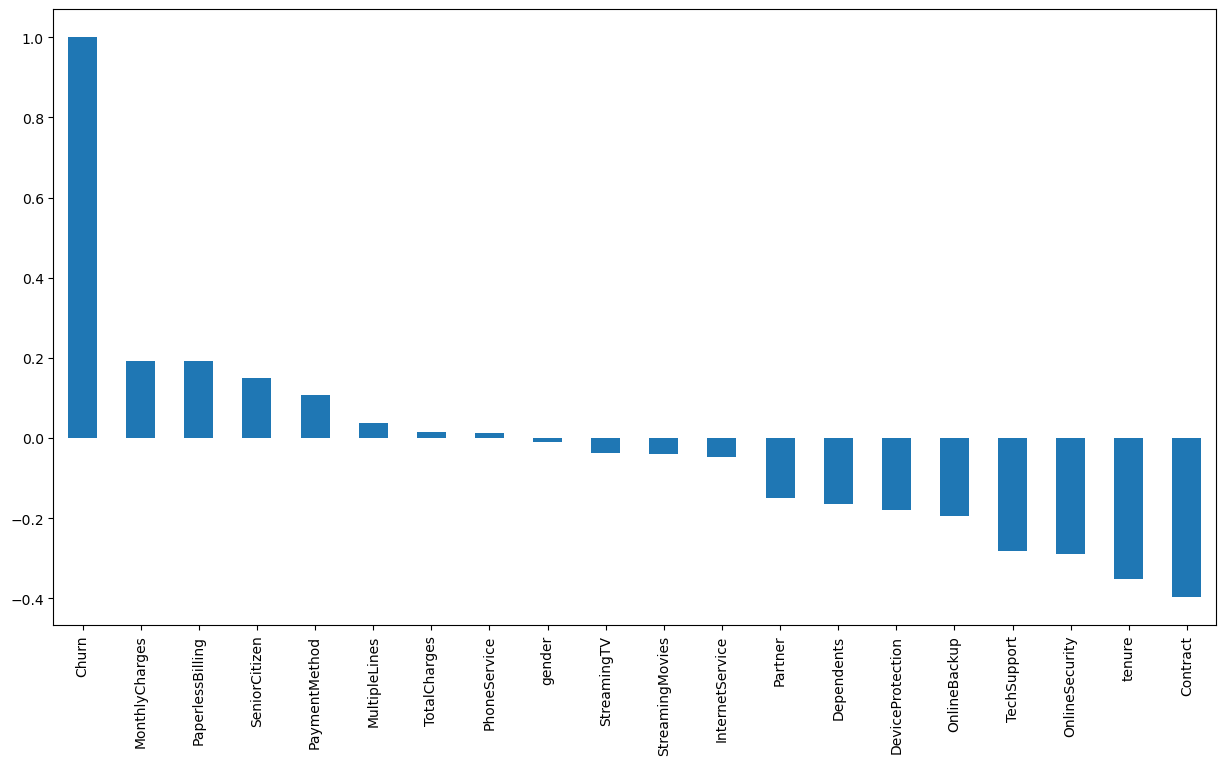

In [11]:
plt.figure(figsize=(15,8))
df.corr()["Churn"].sort_values(ascending=False).plot(kind="bar")
plt.show()

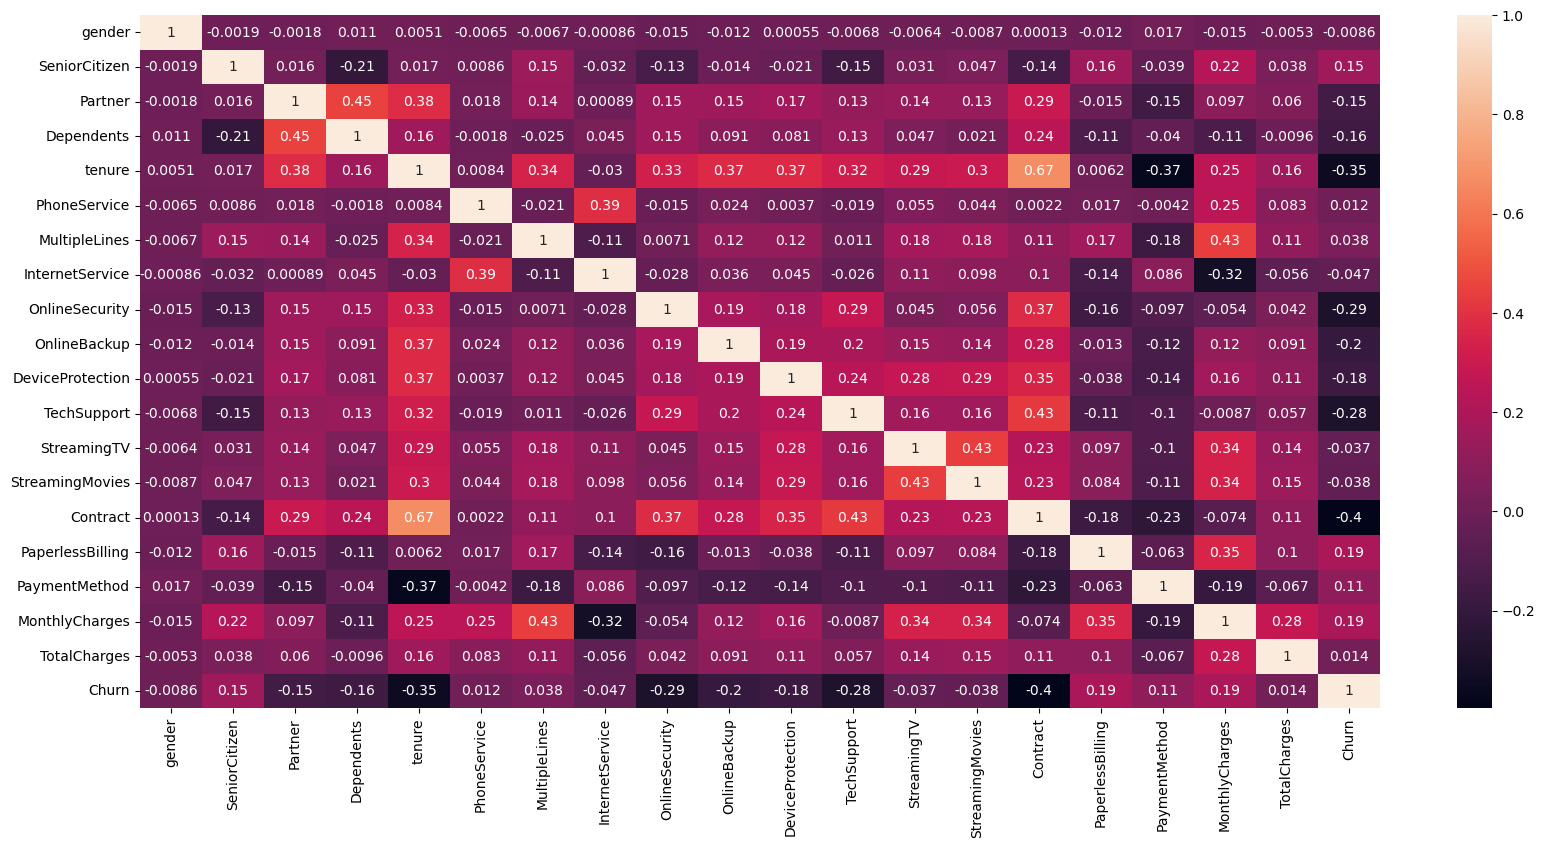

In [12]:
# finding the correlation between the independent and dependent feature.
plt.figure(figsize=(20,9))
sns.heatmap(df.corr(),annot=True)
plt.show()